In [25]:
from google.colab import files
uploaded = files.upload()

Saving ant-1.7.csv to ant-1.7.csv
Saving camel-1.6.csv to camel-1.6.csv
Saving jm1.csv to jm1.csv
Saving kc1.csv to kc1.csv
Saving mc2.csv to mc2.csv
Saving pc3.csv to pc3.csv
Saving xalan-2.4.csv to xalan-2.4.csv
Saving xerces-1.2.csv to xerces-1.2.csv


In [26]:
# SOFTWARE FAULT PREDICTION - Replicating & Extending
# "Modeling Incremental Faults of Software Testing
#  Process Using AR Models" (Sheta & Rine)
#
# Extended with: Deep Learning (LSTM, GRU, Transformer,
# Attention-BiLSTM), Classical ML (RF, XGBoost, SVM),
# and the original AR + Power models from the paper.
#
# Metrics: Accuracy, Training Accuracy, Test Accuracy, Loss

In [27]:
import os, warnings, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import defaultdict

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             mean_squared_error, r2_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau

In [28]:
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost not found – skipping XGB model.")

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False
    print("LightGBM not found – skipping LGB model.")

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid", palette="muted")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n{'='*55}")
print(f"  Software Fault Prediction – Sheta & Rine (Extended)")
print(f"{'='*55}")
print(f"  Device : {DEVICE}")
print(f"  PyTorch: {torch.__version__}")
print(f"  CUDA   : {torch.cuda.is_available()}")
print(f"{'='*55}\n")


  Software Fault Prediction – Sheta & Rine (Extended)
  Device : cuda
  PyTorch: 2.10.0+cu128
  CUDA   : True



In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
DATASET_FILES = {
    "ant-1_7"    : "ant-1.7.csv",
    "camel-1_6"  : "camel-1.6.csv",
    "jm1"        : "jm1.csv",
    "kc1"        : "kc1.csv",
    "mc2"        : "mc2.csv",
    "pc3"        : "pc3.csv",
    "xalan-2_4"  : "xalan-2.4.csv",
    "xerces-1_2" : "xerces-1.2.csv",
}



In [31]:
TARGET_MAP = {
    "ant-1_7"   : "bug",
    "camel-1_6" : "bug",
    "xalan-2_4" : "bug",
    "xerces-1_2": "bug",
    "jm1"       : "defects",
    "kc1"       : "defects",
    "mc2"       : "c",
    "pc3"       : "c",
}


In [32]:
def load_dataset(name: str, path: str) -> tuple:
    """Load CSV, auto-detect target, binarise, return X, y."""
    df = pd.read_csv(path)

    # Strip whitespace from column names
    df.columns = df.columns.str.strip()

    target_col = TARGET_MAP.get(name)
    if target_col is None:
        # Fallback: last column
        target_col = df.columns[-1]

    # Drop rows where target is missing
    df = df.dropna(subset=[target_col])

    # Binarise target  (True/False/yes/no/0/>0)
    raw = df[target_col].astype(str).str.strip().str.lower()
    if raw.isin(["true", "false"]).any():
        y = (raw == "true").astype(int).values
    elif raw.isin(["yes", "no"]).any():
        y = (raw == "yes").astype(int).values
    else:
        numeric = pd.to_numeric(df[target_col], errors="coerce").fillna(0)
        y = (numeric > 0).astype(int).values

    # Feature matrix – drop non-numeric & target
    X = df.drop(columns=[target_col])
    # drop string columns that carry no numeric signal
    X = X.select_dtypes(include=[np.number])

    # Impute NaN with median
    imp = SimpleImputer(strategy="median")
    X = pd.DataFrame(imp.fit_transform(X), columns=X.columns)

    print(f"  [{name}]  shape={df.shape}  features={X.shape[1]}  "
          f"defects={y.sum()} ({100*y.mean():.1f}%)")
    return X.values.astype(np.float32), y.astype(np.int64)


print("Loading datasets …")
DATASETS = {}
for name, path in DATASET_FILES.items():
    if os.path.exists(path):
        try:
            X, y = load_dataset(name, path)
            DATASETS[name] = (X, y)
        except Exception as e:
            print(f"  [WARN] Could not load {name}: {e}")
    else:
        print(f"  [SKIP] {name} – file not found at {path}")

print(f"\nLoaded {len(DATASETS)} datasets.\n")


Loading datasets …
  [ant-1_7]  shape=(745, 24)  features=21  defects=166 (22.3%)
  [camel-1_6]  shape=(965, 24)  features=21  defects=188 (19.5%)
  [jm1]  shape=(13204, 22)  features=21  defects=2103 (15.9%)
  [kc1]  shape=(2109, 22)  features=21  defects=326 (15.5%)
  [mc2]  shape=(161, 40)  features=39  defects=52 (32.3%)
  [pc3]  shape=(1563, 38)  features=37  defects=160 (10.2%)
  [xalan-2_4]  shape=(723, 24)  features=20  defects=110 (15.2%)
  [xerces-1_2]  shape=(440, 24)  features=20  defects=71 (16.1%)

Loaded 8 datasets.



In [34]:
# ════════════════════════════════════════════════════════════
# CELL 3 – AR Model (Paper Replica)
# ════════════════════════════════════════════════════════════

class ARModel:
    """
    Auto-Regression fault prediction model from the paper.
    Uses Least-Squares Estimation (LSE) with lag=4.
    """
    def __init__(self, order: int = 4):
        self.order = order
        self.params = None   # [a0, a1, ..., a_order]

    def _build_matrix(self, mu: np.ndarray):
        n = len(mu)
        rows = []
        for t in range(self.order, n):
            row = [1.0] + [mu[t - j] for j in range(1, self.order + 1)]
            rows.append(row)
        phi = np.array(rows)
        y   = mu[self.order:]
        return phi, y

    def fit(self, mu: np.ndarray):
        """mu: 1-D array of cumulative fault counts."""
        phi, y = self._build_matrix(mu)
        # LSE:  theta = (phi^T phi)^-1 phi^T y
        self.params = np.linalg.lstsq(phi, y, rcond=None)[0]
        return self

    def predict(self, mu_init: np.ndarray, steps: int) -> np.ndarray:
        """
        Predict `steps` future values starting from the last
        `order` known values in mu_init.
        """
        assert self.params is not None, "Call fit() first."
        buf = list(mu_init[-self.order:])
        preds = []
        for _ in range(steps):
            x = [1.0] + buf[-self.order:][::-1]
            val = float(np.dot(self.params, x))
            preds.append(val)
            buf.append(val)
        return np.array(preds)

    def rmse(self, mu: np.ndarray, split: float = 0.7):
        n = len(mu)
        split_idx = int(n * split)
        phi_train, y_train = self._build_matrix(mu[:split_idx])
        phi_test,  y_test  = self._build_matrix(mu)

        y_hat_train = phi_train @ self.params
        y_hat_test  = self.predict(mu[:split_idx], len(y_test))

        rmse_tr = np.sqrt(np.mean((y_train - y_hat_train) ** 2))
        rmse_te = np.sqrt(np.mean((y_test  - y_hat_test)  ** 2))
        return rmse_tr, rmse_te


class PowerModel:
    """Power model: μ(t) = β0 * t^β1 (LSE in log-space)."""
    def __init__(self):
        self.b0 = self.b1 = None

    def fit(self, mu: np.ndarray):
        t = np.arange(1, len(mu) + 1, dtype=float)
        log_t  = np.log(t)
        log_mu = np.log(np.clip(mu, 1e-9, None))
        A = np.column_stack([np.ones_like(log_t), log_t])
        coeffs = np.linalg.lstsq(A, log_mu, rcond=None)[0]
        self.b0 = np.exp(coeffs[0])
        self.b1 = coeffs[1]
        return self

    def predict(self, t_vals: np.ndarray) -> np.ndarray:
        return self.b0 * (t_vals ** self.b1)

    def rmse(self, mu: np.ndarray, split: float = 0.7):
        n = len(mu)
        split_idx = int(n * split)
        t_all = np.arange(1, n + 1, dtype=float)
        self.fit(mu[:split_idx])
        y_hat_train = self.predict(t_all[:split_idx])
        y_hat_test  = self.predict(t_all[split_idx:])
        rmse_tr = np.sqrt(np.mean((mu[:split_idx] - y_hat_train) ** 2))
        rmse_te = np.sqrt(np.mean((mu[split_idx:] - y_hat_test)  ** 2))
        return rmse_tr, rmse_te

In [35]:
# ════════════════════════════════════════════════════════════
# CELL 4 – Deep Learning Models
# ════════════════════════════════════════════════════════════

# ── 4a  Attention-BiLSTM ──────────────────────────────────
class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)

    def forward(self, lstm_out):          # (B, T, H*2)
        scores = self.attn(lstm_out)      # (B, T, 1)
        weights = torch.softmax(scores, dim=1)
        context = (weights * lstm_out).sum(dim=1)
        return context, weights


class AttentionBiLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2,
                 dropout=0.3, num_classes=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.attention = AttentionLayer(hidden_dim)
        self.bn   = nn.BatchNorm1d(hidden_dim * 2)
        self.drop = nn.Dropout(dropout)
        self.fc1  = nn.Linear(hidden_dim * 2, 64)
        self.fc2  = nn.Linear(64, num_classes)
        self.act  = nn.GELU()

    def forward(self, x):                 # x: (B, T, F)
        out, _ = self.lstm(x)
        ctx, _ = self.attention(out)
        ctx = self.bn(ctx)
        ctx = self.drop(self.act(self.fc1(ctx)))
        return self.fc2(ctx)

In [36]:
# ── 4b  GRU with residual connections ────────────────────
class ResGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=3,
                 dropout=0.3, num_classes=2):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers,
                          batch_first=True, bidirectional=True,
                          dropout=dropout if num_layers > 1 else 0)
        self.proj = nn.Linear(input_dim, hidden_dim * 2)   # residual
        self.bn   = nn.BatchNorm1d(hidden_dim * 2)
        self.drop = nn.Dropout(dropout)
        self.fc1  = nn.Linear(hidden_dim * 2, 64)
        self.fc2  = nn.Linear(64, num_classes)
        self.act  = nn.GELU()

    def forward(self, x):
        out, _ = self.gru(x)
        ctx = out[:, -1, :]
        res = self.proj(x[:, -1, :])
        ctx = self.bn(ctx + res)
        ctx = self.drop(self.act(self.fc1(ctx)))
        return self.fc2(ctx)

In [37]:
# ── 4c  Transformer Encoder ──────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * -(np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.drop(x + self.pe[:, :x.size(1)])


class TransformerClassifier(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4,
                 num_layers=3, dropout=0.1, num_classes=2):
        super().__init__()
        self.proj = nn.Linear(input_dim, d_model)
        self.pe   = PositionalEncoding(d_model, dropout=dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward=256,
            dropout=dropout, batch_first=True, activation='gelu')
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.pe(self.proj(x))
        x = self.encoder(x)
        x = self.pool(x.transpose(1, 2)).squeeze(-1)
        return self.fc(x)

In [38]:
# ── 4d  1-D CNN + BiGRU hybrid ───────────────────────────
class CNN_BiGRU(nn.Module):
    def __init__(self, input_dim, num_classes=2, dropout=0.3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.GELU(),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.GELU(),
        )
        self.gru  = nn.GRU(128, 64, 2, batch_first=True,
                           bidirectional=True, dropout=dropout)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Sequential(
            nn.Linear(128, 32), nn.GELU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):                 # x: (B, T, F)
        x = x.transpose(1, 2)            # (B, F, T) for Conv1d
        x = self.conv(x)
        x = x.transpose(1, 2)            # (B, T, 128)
        out, _ = self.gru(x)
        ctx = self.drop(out[:, -1, :])
        return self.fc(ctx)


# ── 4e  Simple MLP baseline ──────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes=2, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.BatchNorm1d(128),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, 64), nn.GELU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x may be (B,1,F) from sequence wrapper – flatten
        if x.dim() == 3:
            x = x.squeeze(1)
        return self.net(x)

In [39]:
# ════════════════════════════════════════════════════════════
# CELL 5 – Training Engine
# ════════════════════════════════════════════════════════════

def make_loaders(X_tr, y_tr, X_te, y_te, seq_len=1,
                 batch_size=64, as_seq=False):
    """
    Wrap numpy arrays into DataLoaders.
    as_seq=True  → shape (B, seq_len, features)  for RNN/Transformer
    as_seq=False → shape (B, features)            for MLP
    """
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr).astype(np.float32)
    X_te = scaler.transform(X_te).astype(np.float32)

    if as_seq:
        X_tr = X_tr[:, np.newaxis, :]   # (B, 1, F)
        X_te = X_te[:, np.newaxis, :]

    Xt = torch.tensor(X_tr); yt = torch.tensor(y_tr, dtype=torch.long)
    Xv = torch.tensor(X_te); yv = torch.tensor(y_te, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(Xt, yt),
                              batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(TensorDataset(Xv, yv),
                              batch_size=256, shuffle=False)
    return train_loader, test_loader, scaler


def train_dl_model(model, train_loader, test_loader,
                   epochs=60, lr=1e-3, patience=12,
                   label_smooth=0.05):
    """
    Train a PyTorch model.
    Returns: history dict with keys
        train_loss, train_acc, val_loss, val_acc
    """
    model = model.to(DEVICE)
    # Class-weighted loss to handle imbalance
    all_y = []
    for _, yb in train_loader:
        all_y.extend(yb.numpy())
    counts = np.bincount(all_y)
    weights = torch.tensor(
        [1.0 / c for c in counts], dtype=torch.float32).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=weights,
                                    label_smoothing=label_smooth)
    optimizer = optim.AdamW(model.parameters(), lr=lr,
                            weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

    history = defaultdict(list)
    best_val_acc = 0.0
    best_state   = None
    no_improve   = 0

    for epoch in range(1, epochs + 1):
        # ── Train ─────────────────────────────────────────
        model.train()
        tot_loss = tot_correct = tot_n = 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(Xb)
            loss   = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tot_loss    += loss.item() * len(yb)
            tot_correct += (logits.argmax(1) == yb).sum().item()
            tot_n       += len(yb)

        train_loss = tot_loss / tot_n
        train_acc  = tot_correct / tot_n

        # ── Validate ──────────────────────────────────────
        model.eval()
        val_loss = val_correct = val_n = 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                logits = model(Xb)
                val_loss    += criterion(logits, yb).item() * len(yb)
                val_correct += (logits.argmax(1) == yb).sum().item()
                val_n       += len(yb)
        val_loss /= val_n
        val_acc   = val_correct / val_n

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.cpu().clone()
                            for k, v in model.state_dict().items()}
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"    Early stopping at epoch {epoch}")
                break

        if epoch % 10 == 0 or epoch == 1:
            print(f"    Epoch {epoch:3d}│ "
                  f"Loss {train_loss:.4f} → {val_loss:.4f}│ "
                  f"Acc {train_acc:.4f} → {val_acc:.4f}")

    model.load_state_dict(best_state)
    return model, history, best_val_acc


def evaluate_model(model, loader):
    """Return accuracy and all predictions."""
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(DEVICE)
            out = model(Xb).argmax(1).cpu().numpy()
            preds.extend(out)
            trues.extend(yb.numpy())
    acc = accuracy_score(trues, preds)
    return acc, np.array(trues), np.array(preds)

In [40]:
# ════════════════════════════════════════════════════════════
# CELL 6 – Classical ML Models
# ════════════════════════════════════════════════════════════

def build_classical_models():
    models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=300, max_depth=None,
            min_samples_split=2, class_weight="balanced",
            random_state=SEED, n_jobs=-1),
        "SVM-RBF": SVC(
            C=10, gamma="scale", kernel="rbf",
            class_weight="balanced", probability=True,
            random_state=SEED),
        "LogisticReg": LogisticRegression(
            max_iter=1000, class_weight="balanced",
            solver="lbfgs", C=1.0, random_state=SEED),
    }
    if XGB_AVAILABLE:
        models["XGBoost"] = xgb.XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            use_label_encoder=False, eval_metric="logloss",
            random_state=SEED, n_jobs=-1)
    if LGB_AVAILABLE:
        models["LightGBM"] = lgb.LGBMClassifier(
            n_estimators=300, num_leaves=63,
            learning_rate=0.05, class_weight="balanced",
            random_state=SEED, n_jobs=-1, verbose=-1)
    return models


def run_classical(X_tr, y_tr, X_te, y_te):
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    # SMOTE on training data to handle class imbalance
    try:
        sm = SMOTE(random_state=SEED, k_neighbors=min(5, y_tr.sum()-1))
        X_tr_s, y_tr = sm.fit_resample(X_tr_s, y_tr)
    except Exception:
        pass  # skip if too few samples

    results = {}
    for name, clf in build_classical_models().items():
        clf.fit(X_tr_s, y_tr)
        tr_acc = accuracy_score(y_tr, clf.predict(X_tr_s))
        te_acc = accuracy_score(y_te, clf.predict(X_te_s))
        results[name] = {"train_acc": tr_acc, "test_acc": te_acc}
        print(f"    {name:<14} train={tr_acc:.4f}  test={te_acc:.4f}")
    return results


# ════════════════════════════════════════════════════════════
# CELL 7 – Main Experiment Loop
# ════════════════════════════════════════════════════════════

ALL_RESULTS = {}   # {dataset_name: {model_name: metrics_dict}}

DL_CONFIGS = {
    "MLP": {
        "model_fn" : lambda d: MLP(d),
        "as_seq"   : False,
        "epochs"   : 80,
        "lr"       : 5e-4,
    },
    "Attn-BiLSTM": {
        "model_fn" : lambda d: AttentionBiLSTM(d, hidden_dim=128, num_layers=2),
        "as_seq"   : True,
        "epochs"   : 80,
        "lr"       : 5e-4,
    },
    "ResGRU": {
        "model_fn" : lambda d: ResGRU(d, hidden_dim=128, num_layers=3),
        "as_seq"   : True,
        "epochs"   : 80,
        "lr"       : 5e-4,
    },
    "Transformer": {
        "model_fn" : lambda d: TransformerClassifier(d, d_model=64, nhead=4, num_layers=3),
        "as_seq"   : True,
        "epochs"   : 80,
        "lr"       : 3e-4,
    },
    "CNN-BiGRU": {
        "model_fn" : lambda d: CNN_BiGRU(d),
        "as_seq"   : True,
        "epochs"   : 80,
        "lr"       : 5e-4,
    },
}


for ds_name, (X, y) in DATASETS.items():
    print(f"\n{'━'*55}")
    print(f"  DATASET: {ds_name}   ({len(X)} samples, {X.shape[1]} features)")
    print(f"{'━'*55}")

    ds_results = {}
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.30, random_state=SEED, stratify=y)

    # ── Classical ML ────────────────────────────────────────
    print("\n  [Classical ML]")
    cl_res = run_classical(X_tr, y_tr, X_te, y_te)
    for mname, mres in cl_res.items():
        ds_results[mname] = {
            "train_acc" : mres["train_acc"],
            "test_acc"  : mres["test_acc"],
            "accuracy"  : mres["test_acc"],   # alias
        }

    # ── Deep Learning ───────────────────────────────────────
    print("\n  [Deep Learning]")
    input_dim = X.shape[1]

    for model_name, cfg in DL_CONFIGS.items():
        print(f"\n  ► {model_name}")
        model = cfg["model_fn"](input_dim)
        n_params = sum(p.numel() for p in model.parameters())
        print(f"    Parameters: {n_params:,}")

        tr_loader, te_loader, _ = make_loaders(
            X_tr, y_tr, X_te, y_te,
            as_seq=cfg["as_seq"], batch_size=64)

        # SMOTE before DataLoader construction for DL models
        try:
            sm = SMOTE(random_state=SEED,
                       k_neighbors=min(5, y_tr.sum()-1))
            scaler_tmp = StandardScaler()
            X_tr_s = scaler_tmp.fit_transform(X_tr).astype(np.float32)
            X_tr_sm, y_tr_sm = sm.fit_resample(X_tr_s, y_tr)
            # rebuild tensors
            if cfg["as_seq"]:
                Xt = torch.tensor(X_tr_sm[:, np.newaxis, :])
            else:
                Xt = torch.tensor(X_tr_sm)
            yt = torch.tensor(y_tr_sm, dtype=torch.long)
            tr_loader = DataLoader(TensorDataset(Xt, yt),
                                   batch_size=64, shuffle=True)
        except Exception:
            pass

        trained, hist, best_val = train_dl_model(
            model, tr_loader, te_loader,
            epochs=cfg["epochs"], lr=cfg["lr"], patience=15)

        tr_acc_final, _, _ = evaluate_model(trained, tr_loader)
        te_acc_final, trues, preds = evaluate_model(trained, te_loader)

        # Final loss (last epoch)
        final_train_loss = hist["train_loss"][-1]
        final_val_loss   = hist["val_loss"][-1]

        ds_results[model_name] = {
            "train_acc"      : tr_acc_final,
            "test_acc"       : te_acc_final,
            "accuracy"       : te_acc_final,
            "train_loss"     : final_train_loss,
            "val_loss"       : final_val_loss,
            "best_val_acc"   : best_val,
            "history"        : hist,
            "trues"          : trues,
            "preds"          : preds,
        }

        print(f"\n    ✓ Final  Train Acc={tr_acc_final:.4f}  "
              f"Test Acc={te_acc_final:.4f}  "
              f"Val Loss={final_val_loss:.4f}")
        print(f"\n    Classification Report (Test):")
        print(classification_report(trues, preds,
              target_names=["No-fault","Fault"], zero_division=0))

    ALL_RESULTS[ds_name] = ds_results

print("\n\n All experiments complete!\n")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  DATASET: ant-1_7   (745 samples, 21 features)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  [Classical ML]
    RandomForest   train=1.0000  test=0.7991
    SVM-RBF        train=0.9049  test=0.7857
    LogisticReg    train=0.7741  test=0.7812
    XGBoost        train=0.9975  test=0.8125
    LightGBM       train=1.0000  test=0.8259

  [Deep Learning]

  ► MLP
    Parameters: 47,682
    Epoch   1│ Loss 0.6455 → 0.6069│ Acc 0.6469 → 0.7902
    Epoch  10│ Loss 0.4729 → 0.5106│ Acc 0.8049 → 0.7723
    Early stopping at epoch 16

    ✓ Final  Train Acc=0.7420  Test Acc=0.7902  Val Loss=0.5283

    Classification Report (Test):
              precision    recall  f1-score   support

    No-fault       0.90      0.82      0.86       174
       Fault       0.52      0.68      0.59        50

    accuracy                           0.79       224
   macro avg       0.71      0.75      0.73       224
weighted avg       0.82     

In [41]:
# ════════════════════════════════════════════════════════════
# CELL 8 – AR & Power Model on a synthetic cumulative series
#          (replicating Section 9-11 of the paper)
# ════════════════════════════════════════════════════════════

print("=" * 55)
print("  Replicating AR vs Power Model (Paper Sections 9-11)")
print("=" * 55)

# We reconstruct cumulative fault series from the CSV datasets
# by sorting on a proxy column and cumsum-ing the defect flag.

AR_PAPER_RESULTS = {}

for ds_name, (X, y) in DATASETS.items():
    # Build a synthetic cumulative fault series from y
    mu = np.cumsum(y).astype(float)
    if len(mu) < 20:
        continue

    ar  = ARModel(order=4).fit(mu)
    pow_m = PowerModel().fit(mu[:int(len(mu)*0.7)])

    rmse_ar_tr,  rmse_ar_te  = ar.rmse(mu)
    rmse_pow_tr, rmse_pow_te = pow_m.rmse(mu)

    AR_PAPER_RESULTS[ds_name] = {
        "AR":    {"RMSE-Training": rmse_ar_tr,  "RMSE-Testing": rmse_ar_te},
        "Power": {"RMSE-Training": rmse_pow_tr, "RMSE-Testing": rmse_pow_te},
    }

    print(f"\n  [{ds_name}]")
    print(f"    {'Model':<8}  RMSE-Train   RMSE-Test")
    print(f"    {'POWM':<8}  {rmse_pow_tr:>10.4f}   {rmse_pow_te:>10.4f}")
    print(f"    {'AR':<8}  {rmse_ar_tr:>10.4f}   {rmse_ar_te:>10.4f}")

  Replicating AR vs Power Model (Paper Sections 9-11)

  [ant-1_7]
    Model     RMSE-Train   RMSE-Test
    POWM          7.6113       6.2928
    AR            0.4142     113.5581

  [camel-1_6]
    Model     RMSE-Train   RMSE-Test
    POWM         20.9669      95.3610
    AR            0.4050     117.4180

  [jm1]
    Model     RMSE-Train   RMSE-Test
    POWM        481.3908    1264.4509
    AR            0.0104     483.4218

  [kc1]
    Model     RMSE-Train   RMSE-Test
    POWM         86.6884     234.5895
    AR            0.0259      72.8798

  [mc2]
    Model     RMSE-Train   RMSE-Test
    POWM         10.3214      47.9367
    AR            0.4586      38.9158

  [pc3]
    Model     RMSE-Train   RMSE-Test
    POWM         27.5092     117.0606
    AR            0.2975     116.2896

  [xalan-2_4]
    Model     RMSE-Train   RMSE-Test
    POWM          7.3590      25.5764
    AR            0.3459      89.3579

  [xerces-1_2]
    Model     RMSE-Train   RMSE-Test
    POWM         12.233

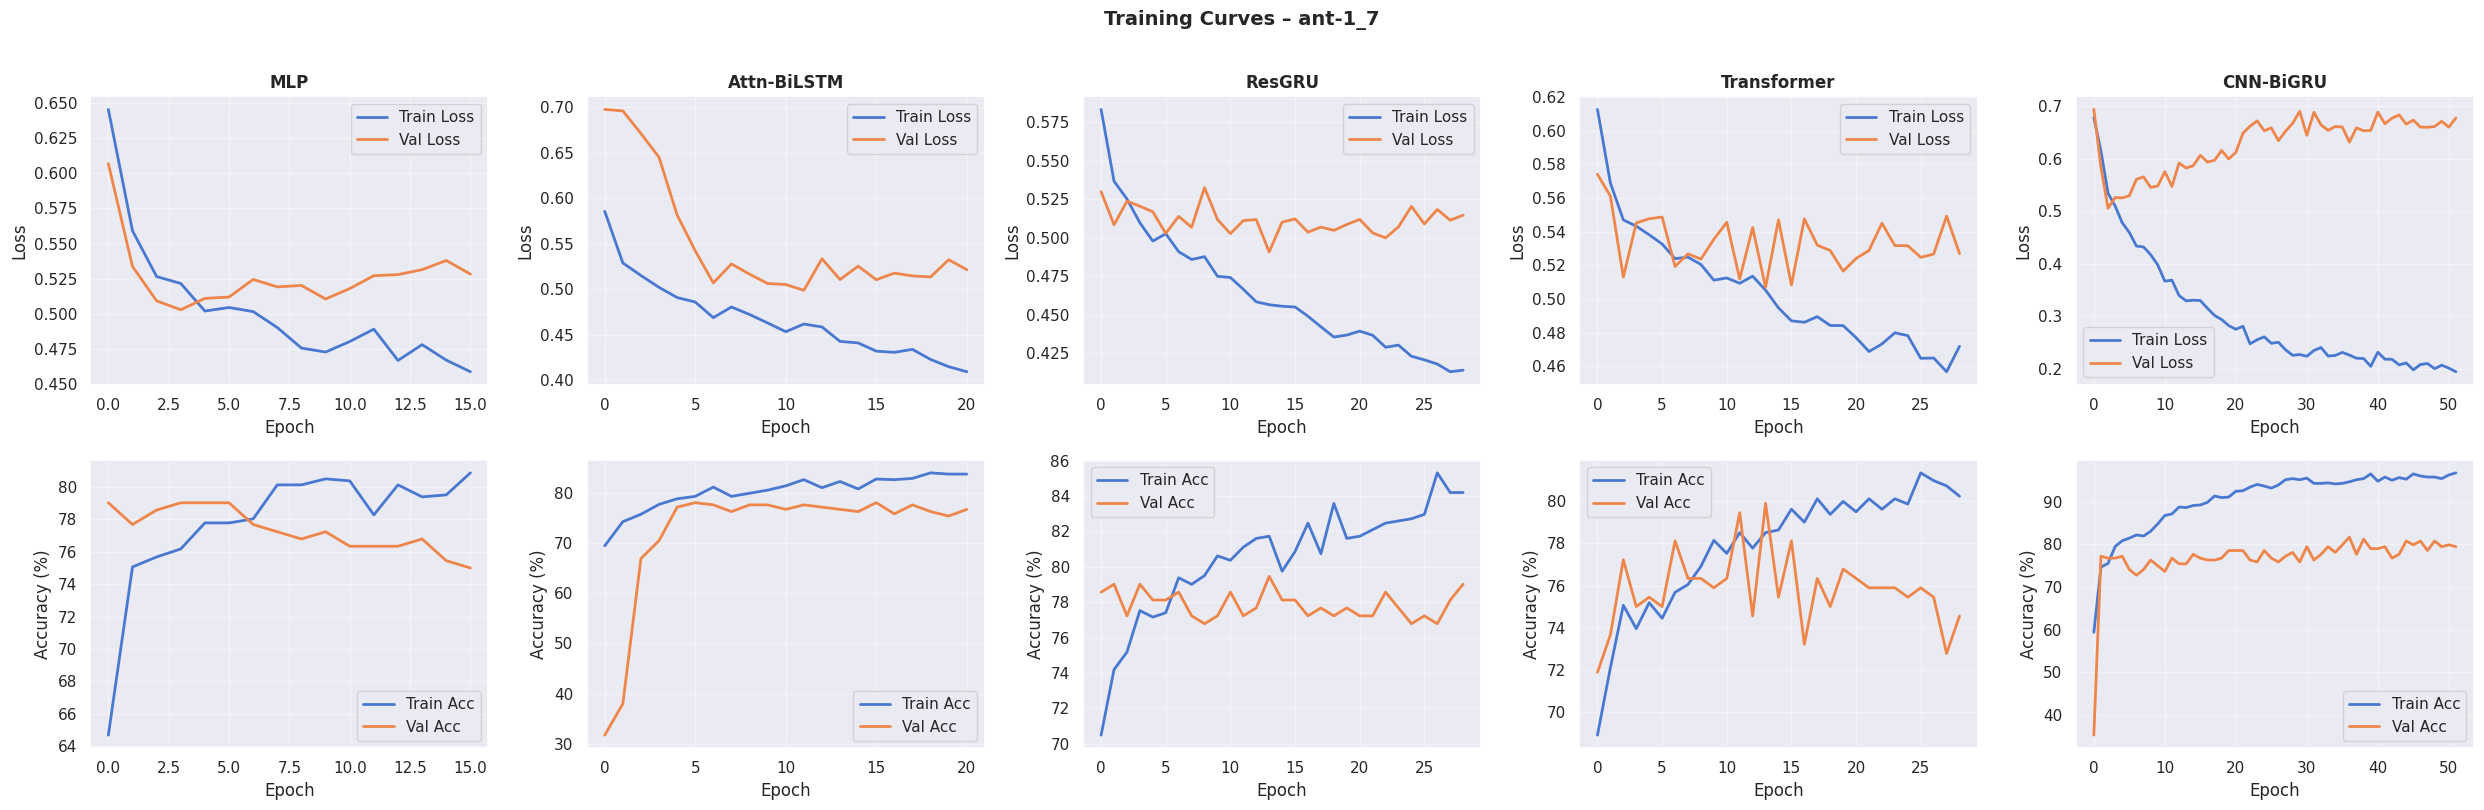

  Saved: training_curves_ant-1_7.png


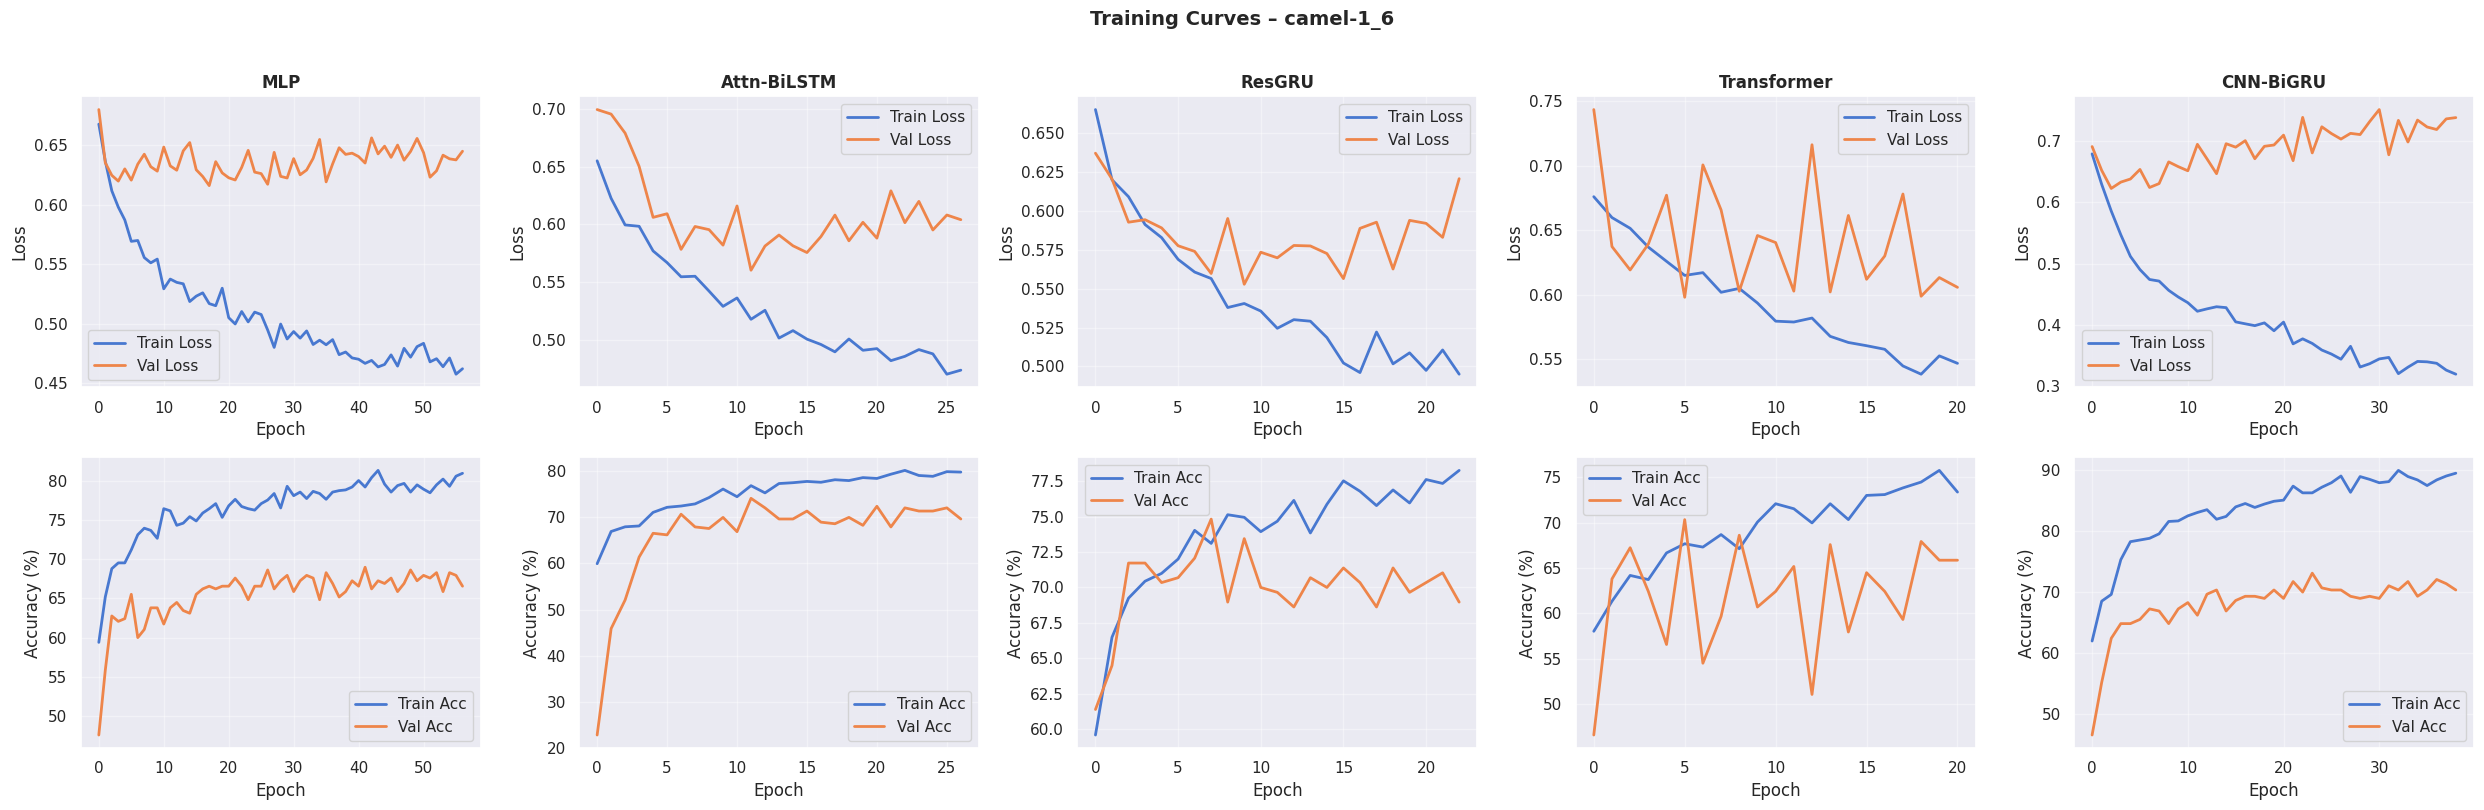

  Saved: training_curves_camel-1_6.png


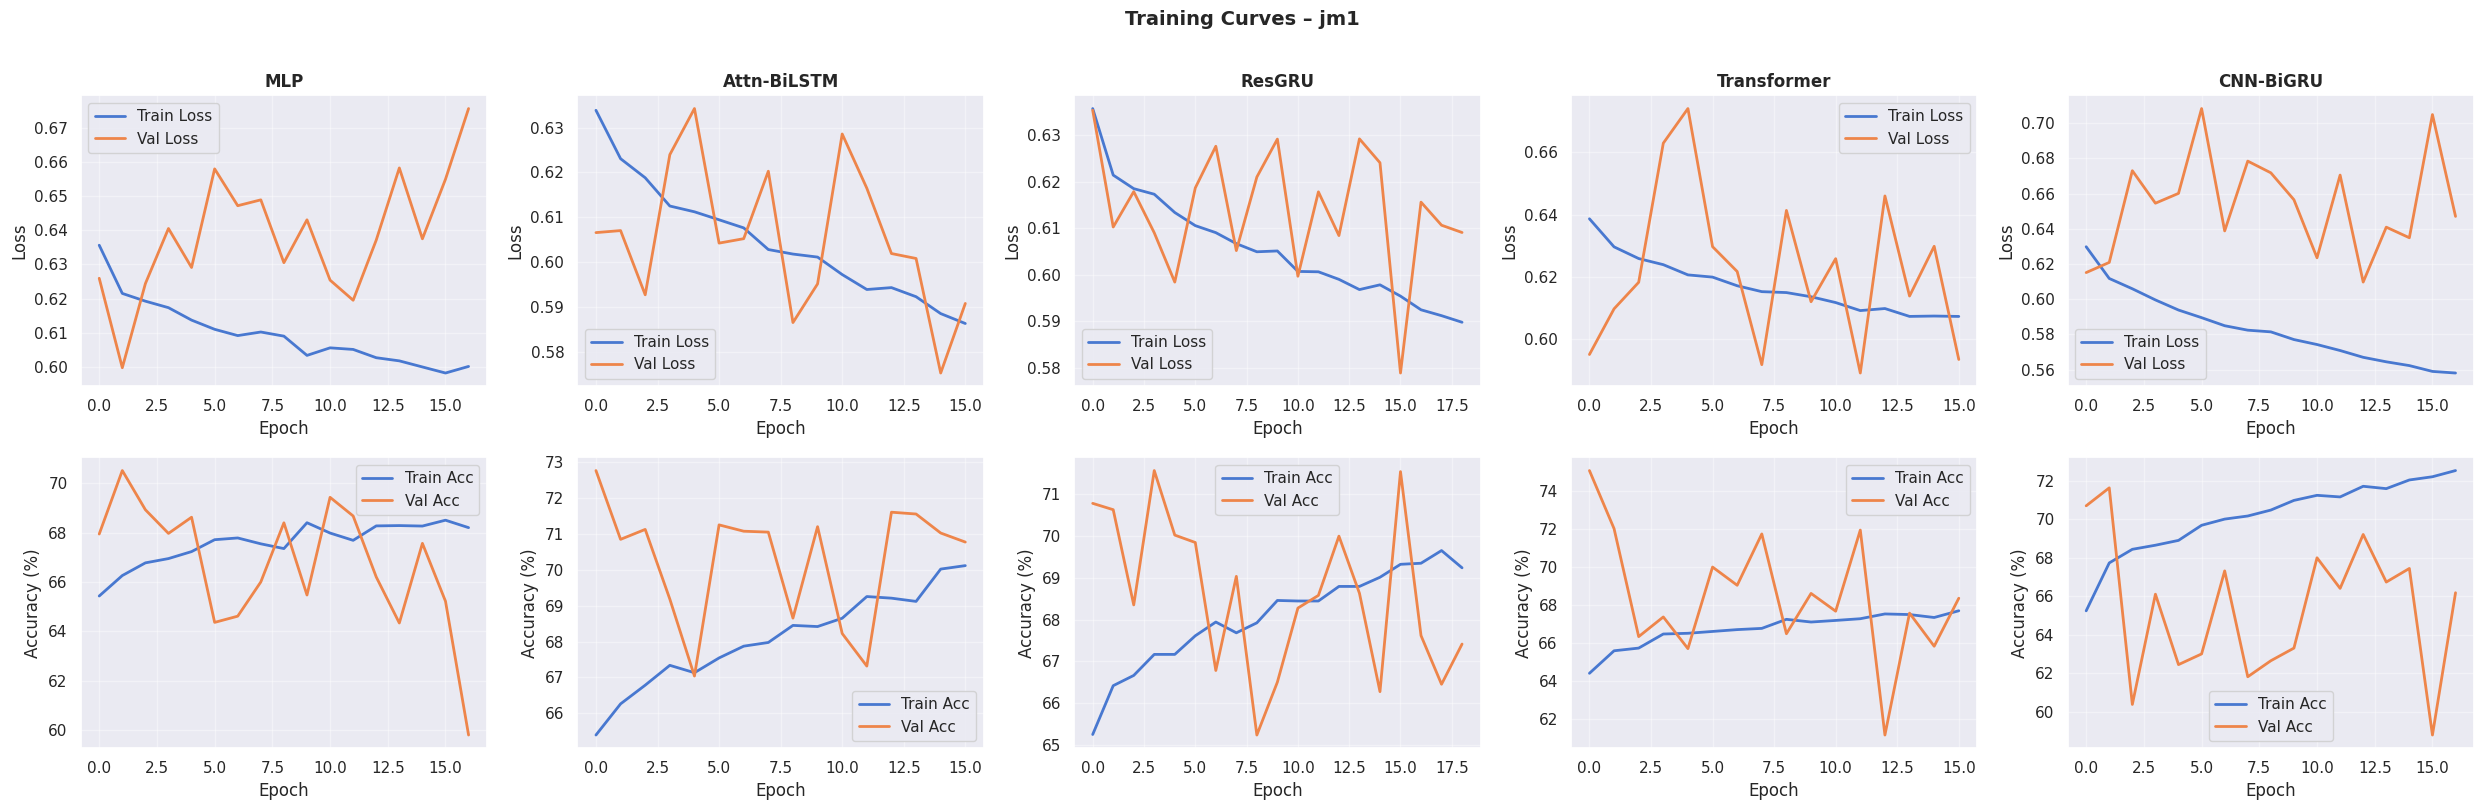

  Saved: training_curves_jm1.png


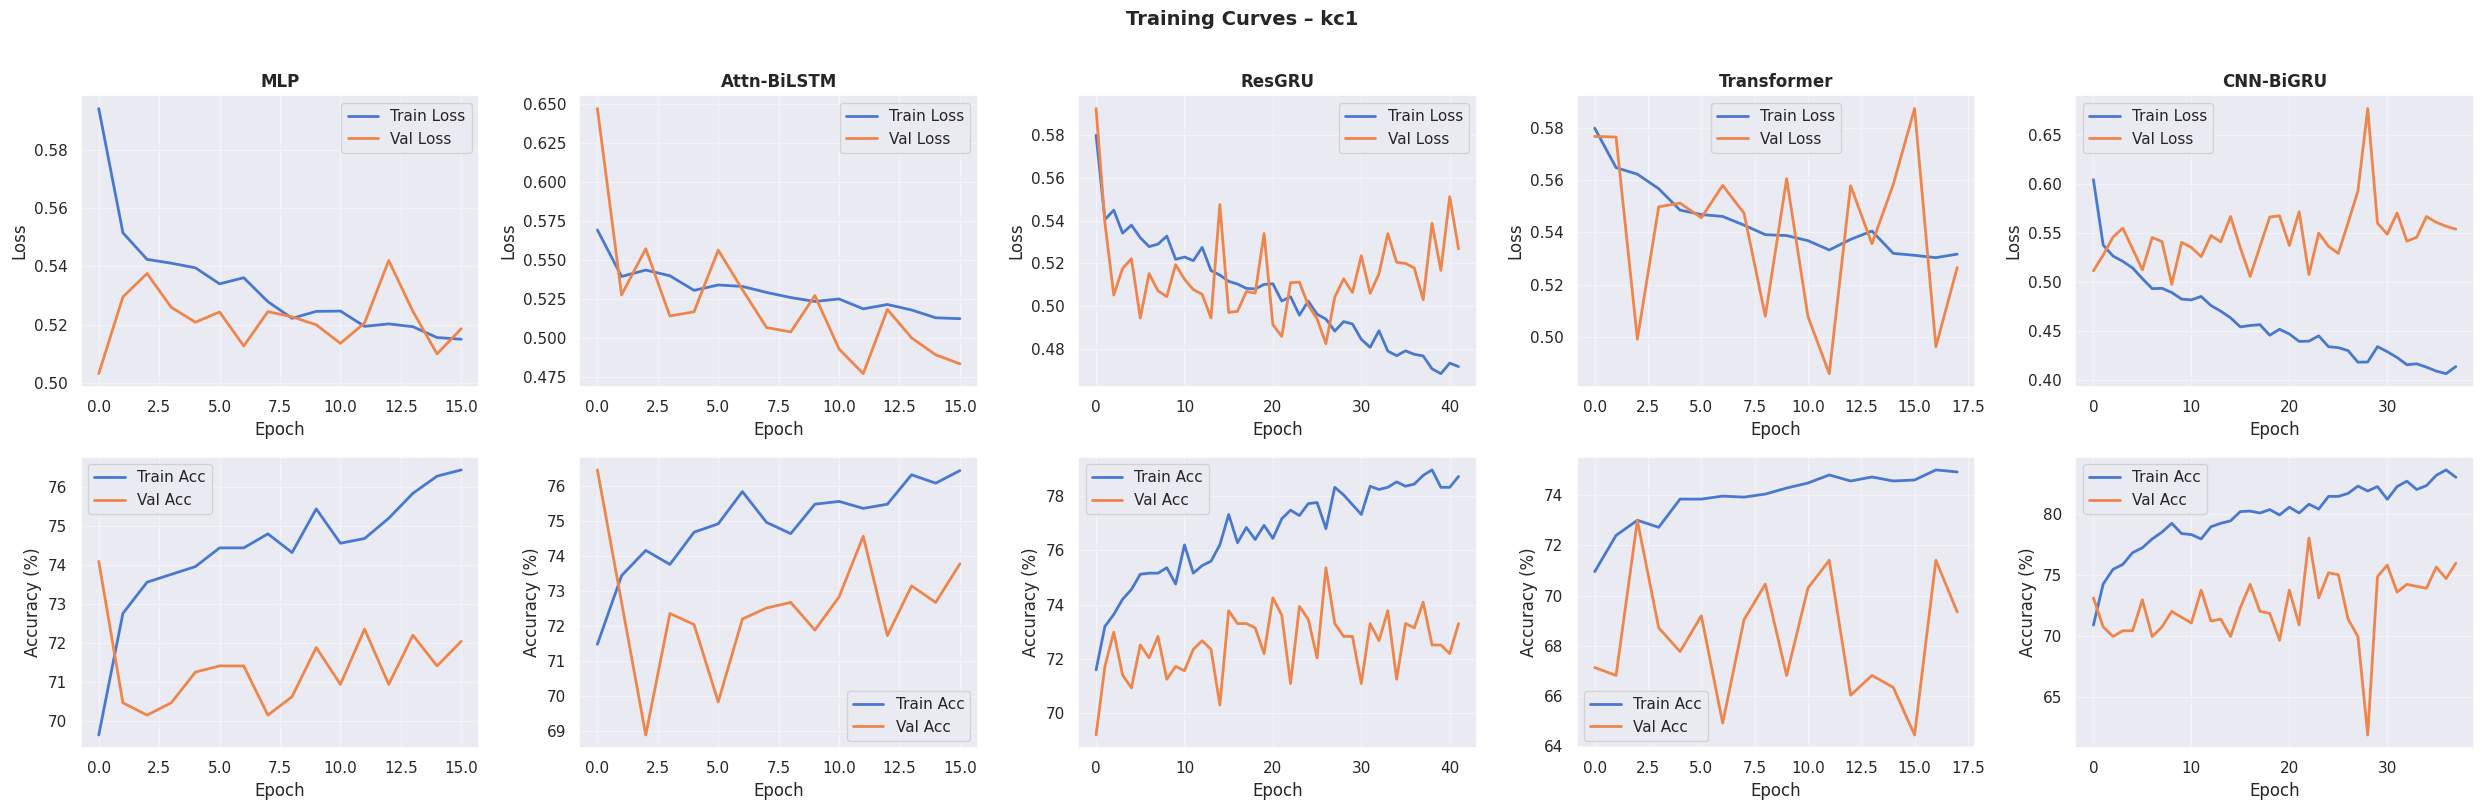

  Saved: training_curves_kc1.png


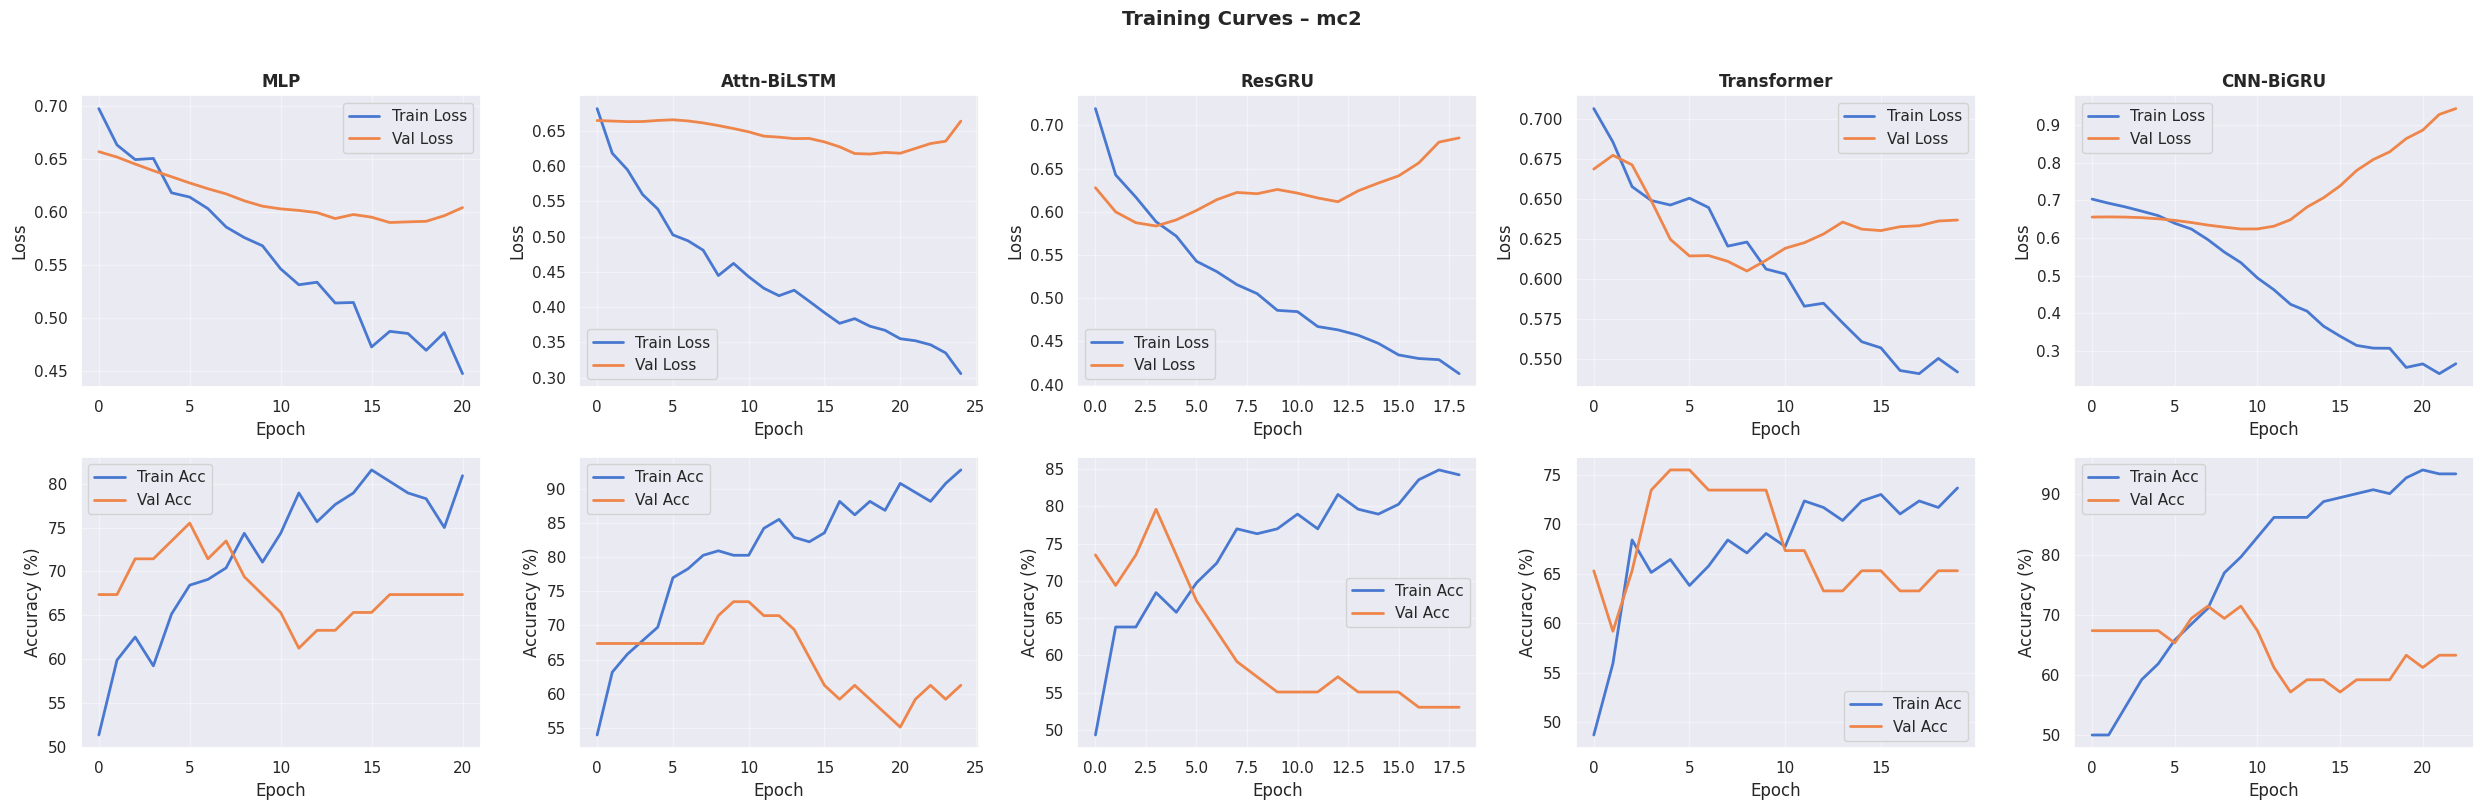

  Saved: training_curves_mc2.png


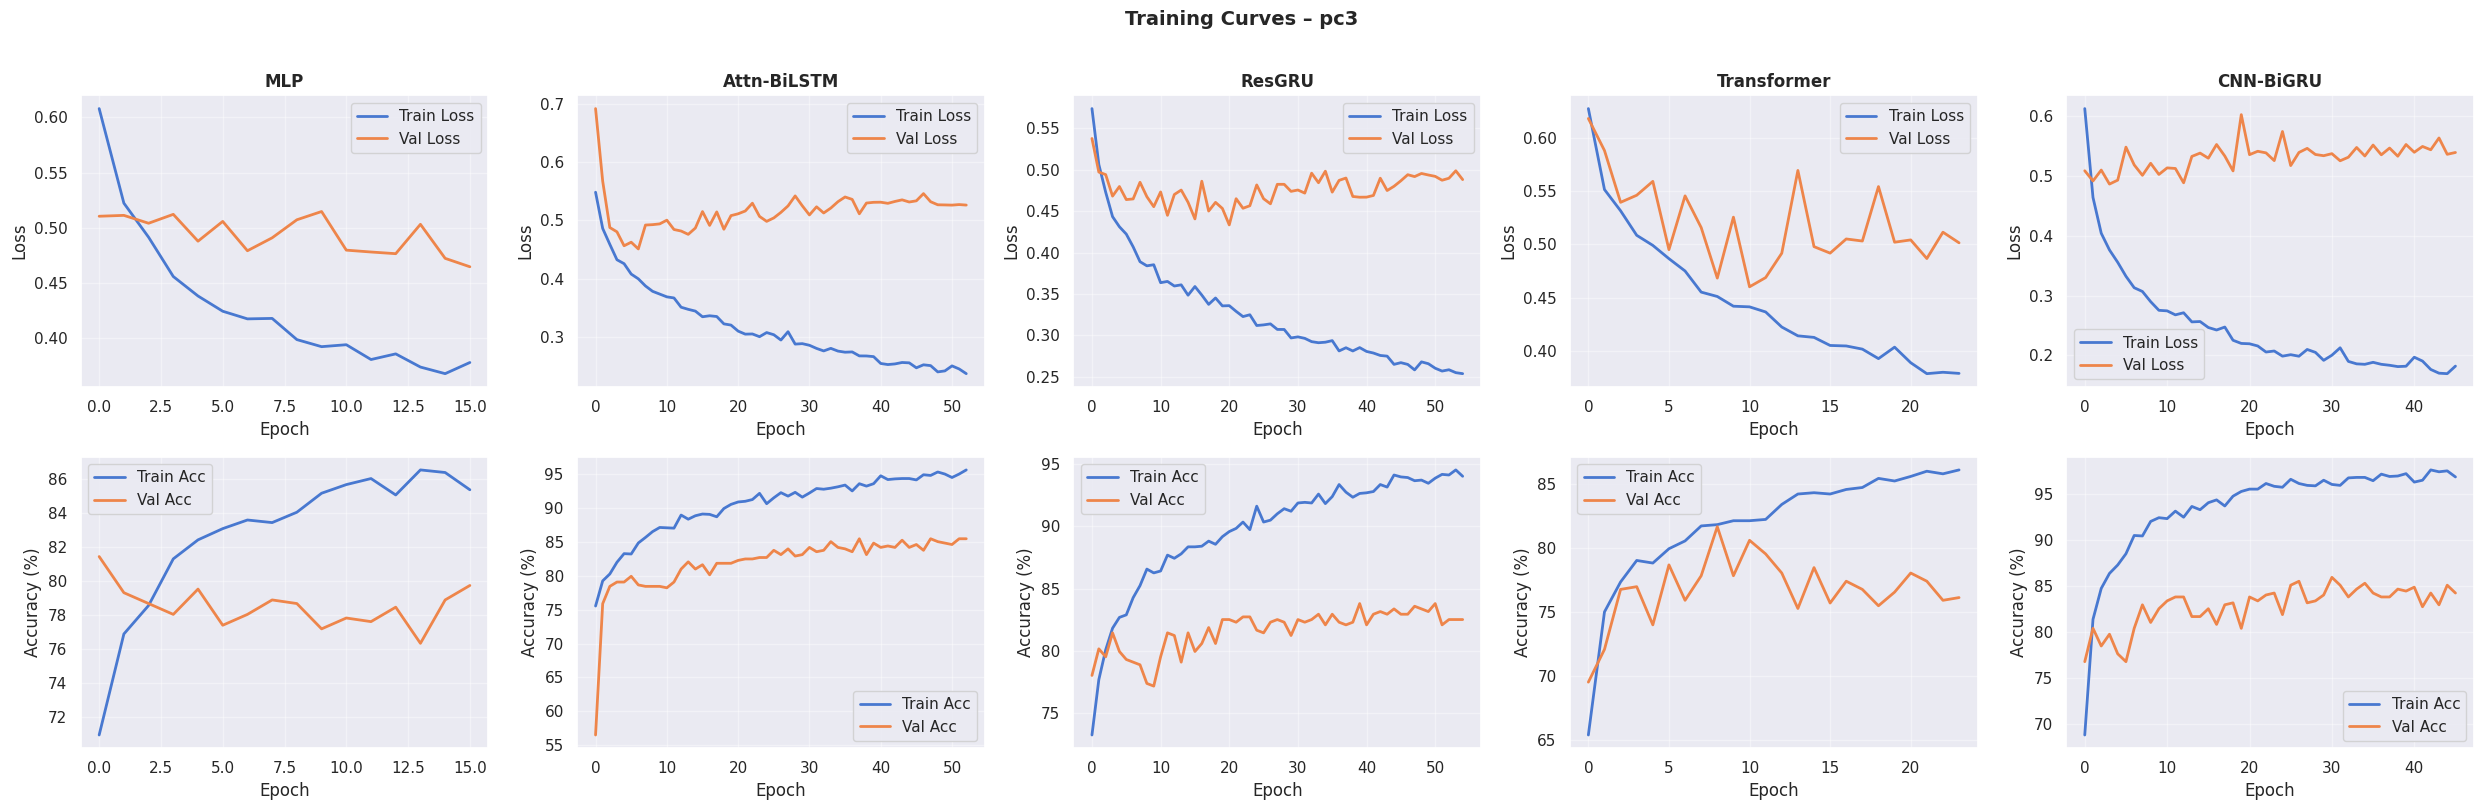

  Saved: training_curves_pc3.png


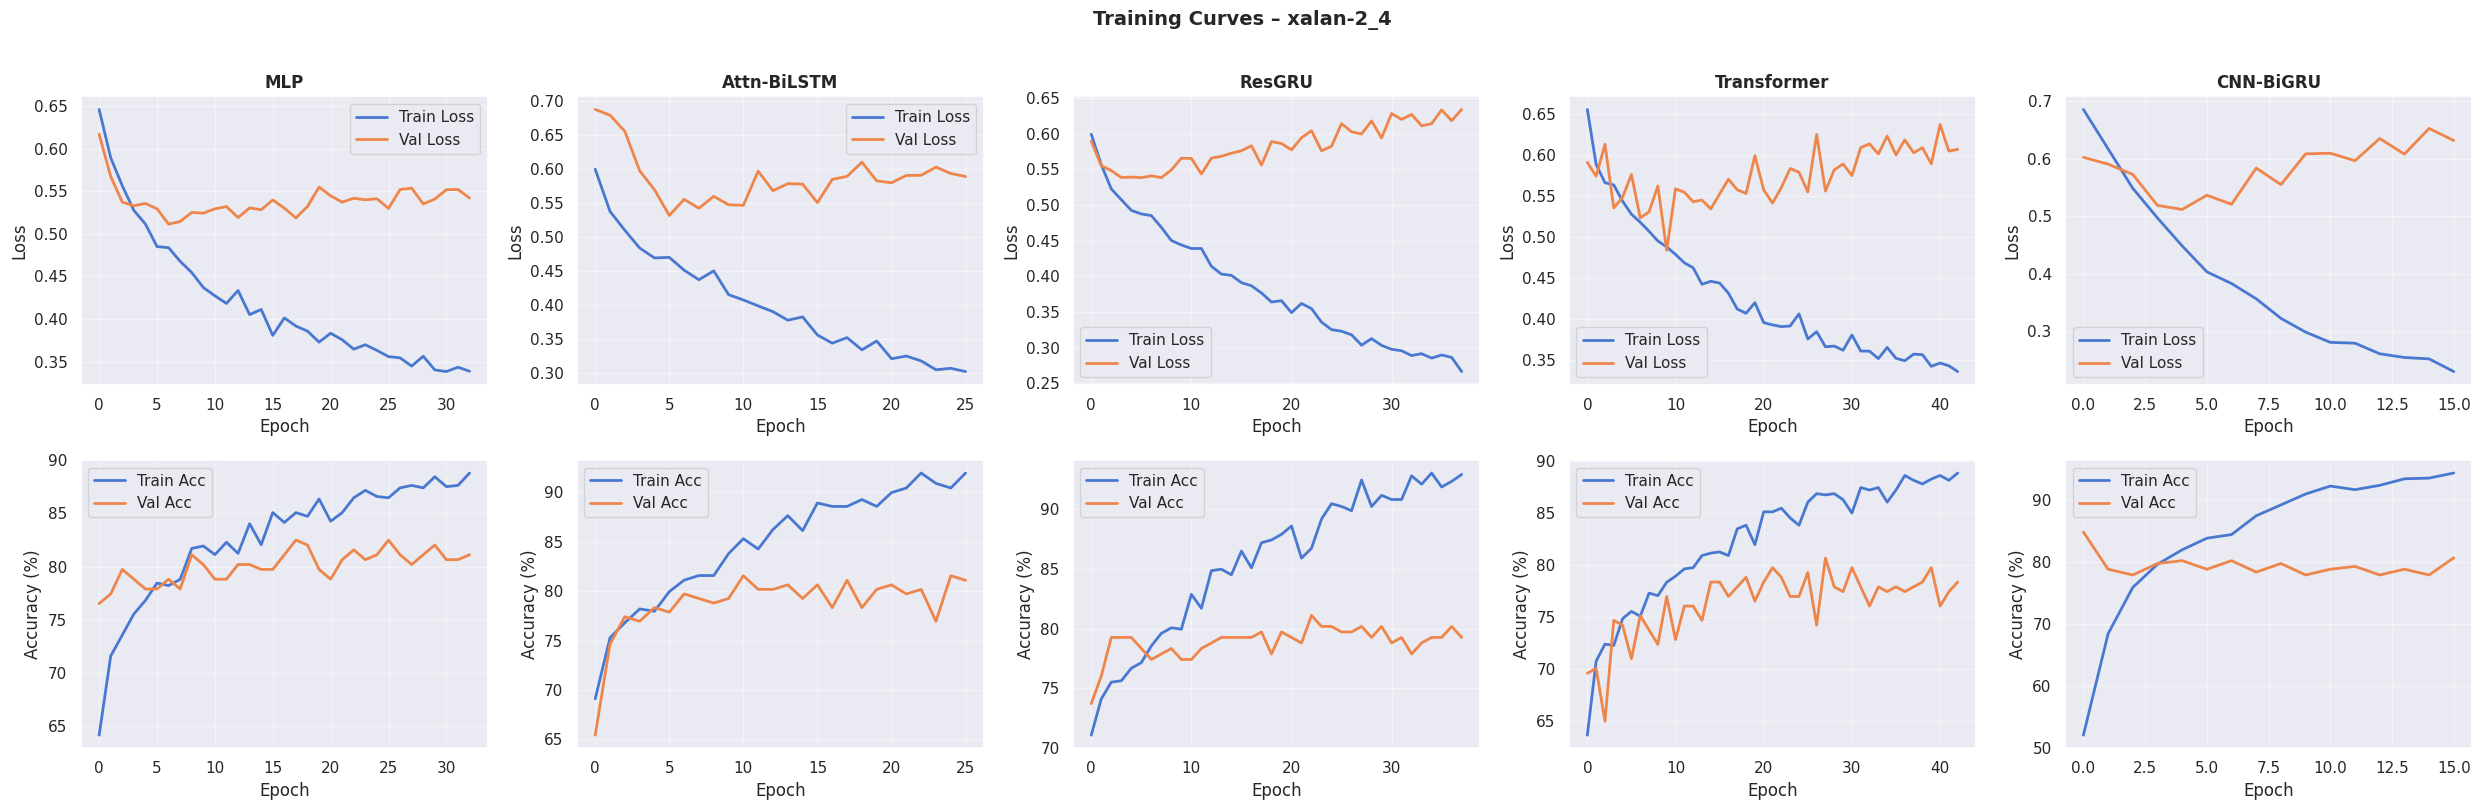

  Saved: training_curves_xalan-2_4.png


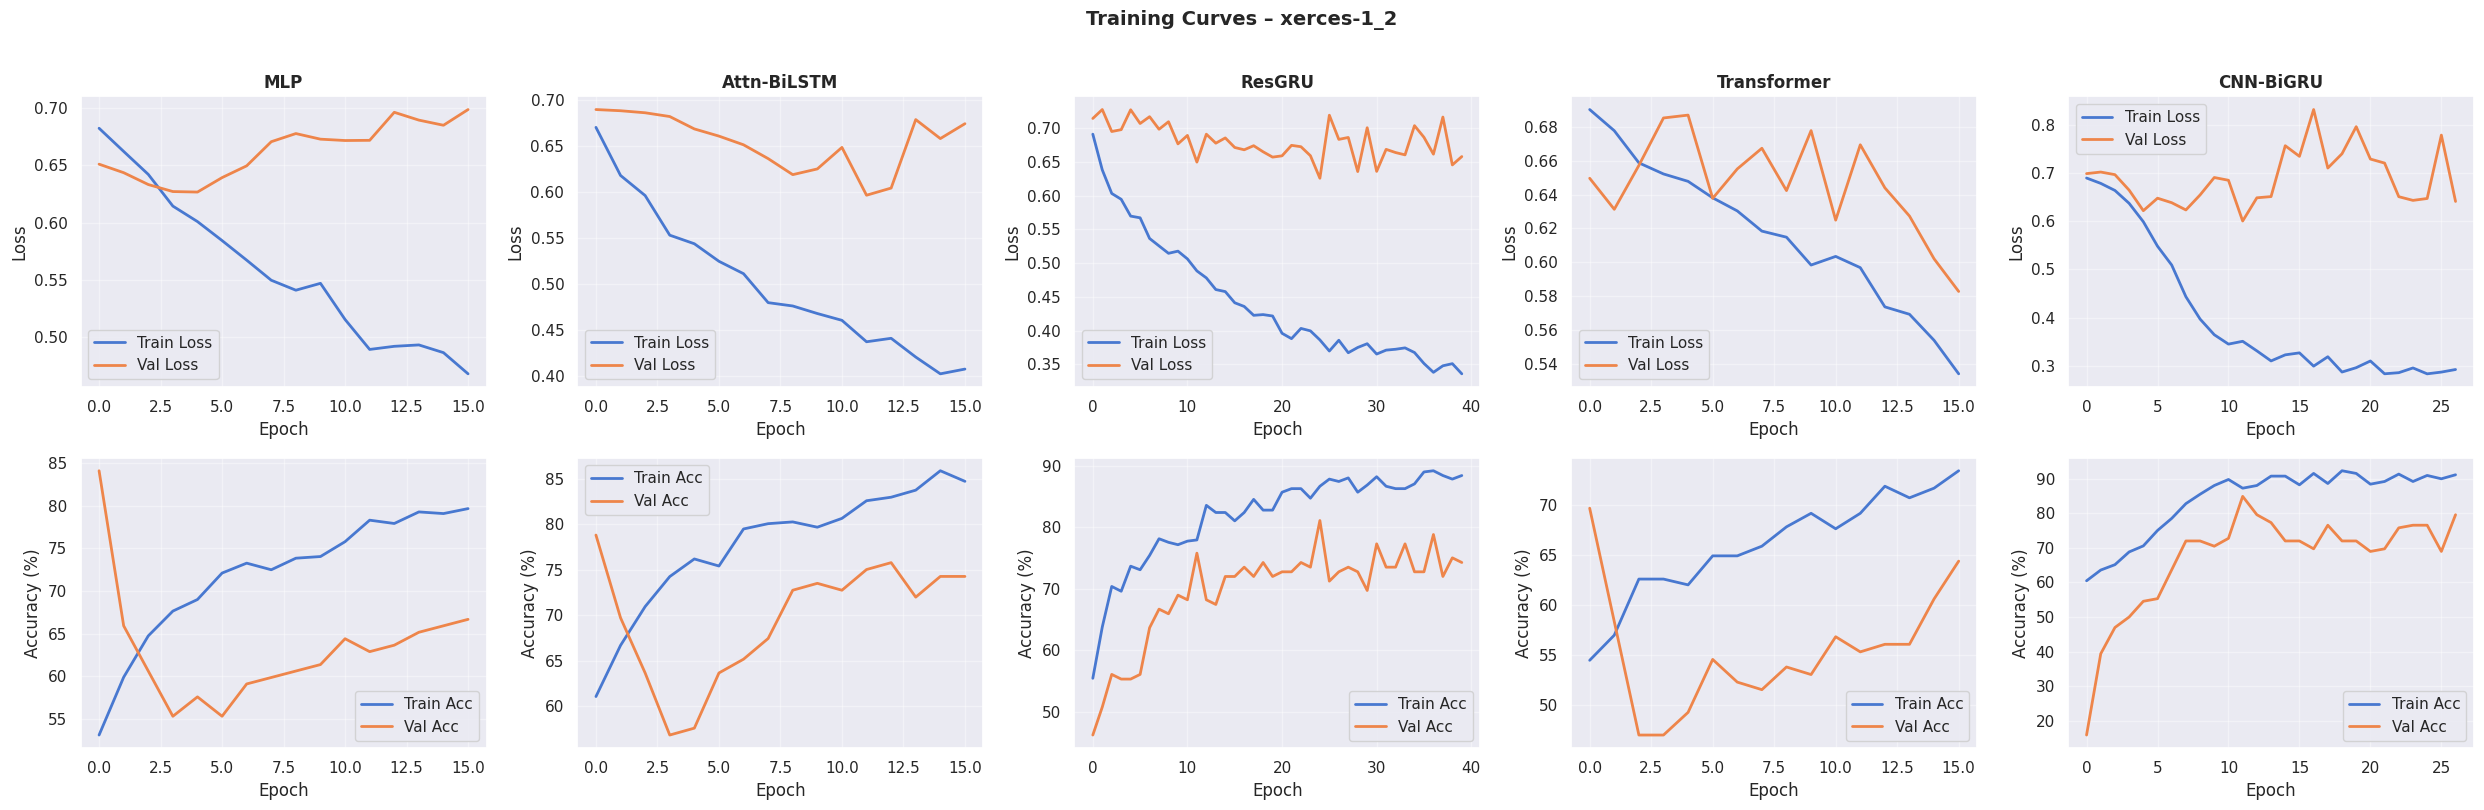

  Saved: training_curves_xerces-1_2.png


  SUMMARY TABLE – Test Accuracy across all Models & Datasets
           Attn-BiLSTM CNN-BiGRU LightGBM LogisticReg     MLP RandomForest  ResGRU SVM-RBF Transformer XGBoost
Dataset                                                                                                       
ant-1_7         78.12%    81.70%   82.59%      78.12%  79.02%       79.91%  79.46%  78.57%      79.91%  81.25%
camel-1_6       74.14%    73.10%   78.97%      63.45%  68.97%       78.62%  74.83%  67.24%      70.34%  78.62%
jm1             72.77%    71.63%   83.90%      71.48%  70.52%       83.77%  71.55%  73.88%      75.09%  83.80%
kc1             76.46%    78.04%   85.15%      74.57%  74.09%       83.41%  75.36%  72.99%      72.99%  86.73%
mc2             73.47%    71.43%   67.35%      61.22%  75.51%       69.39%  79.59%  59.18%      75.51%  67.35%
pc3             85.50%    85.93%   88.06%      79.32%  81.45%       85.71%  83.80%  84.01%      81.66%  86.99%
xalan-2_4

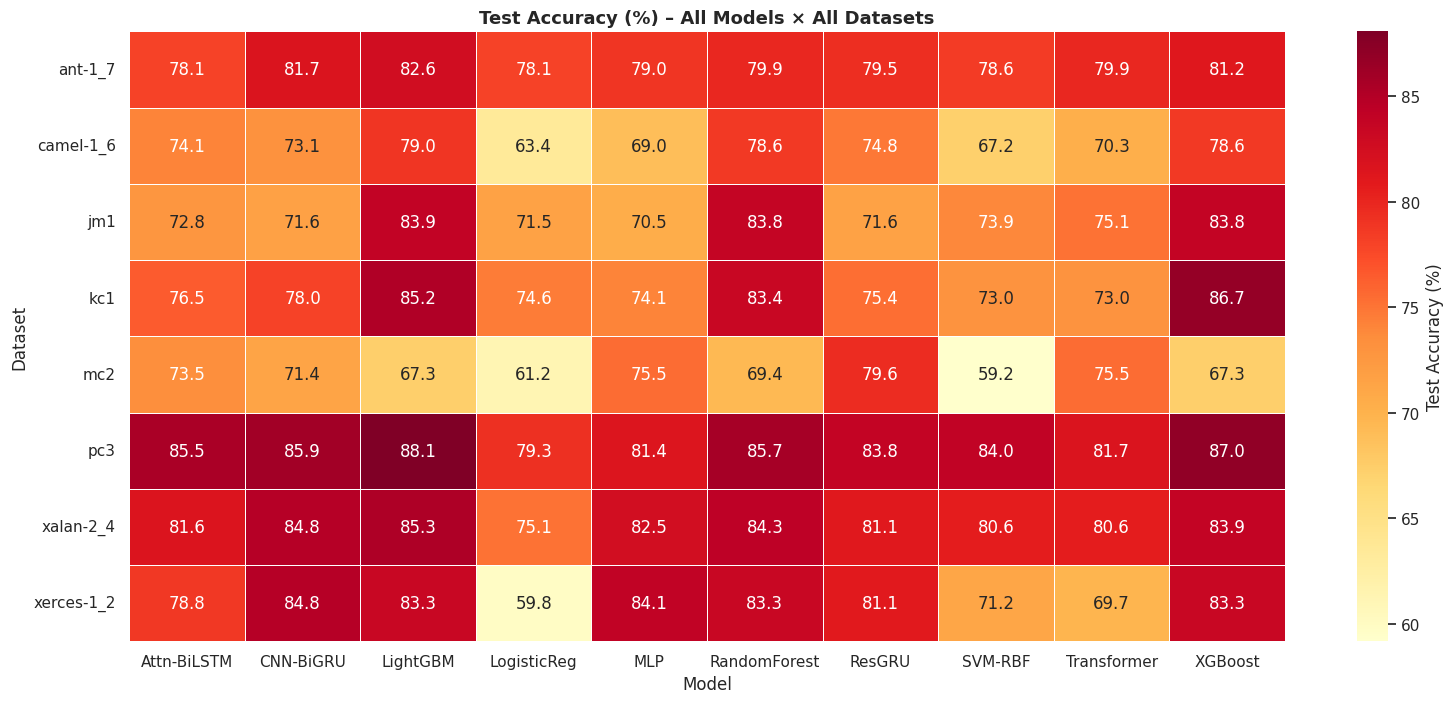


  Saved: heatmap_test_accuracy.png


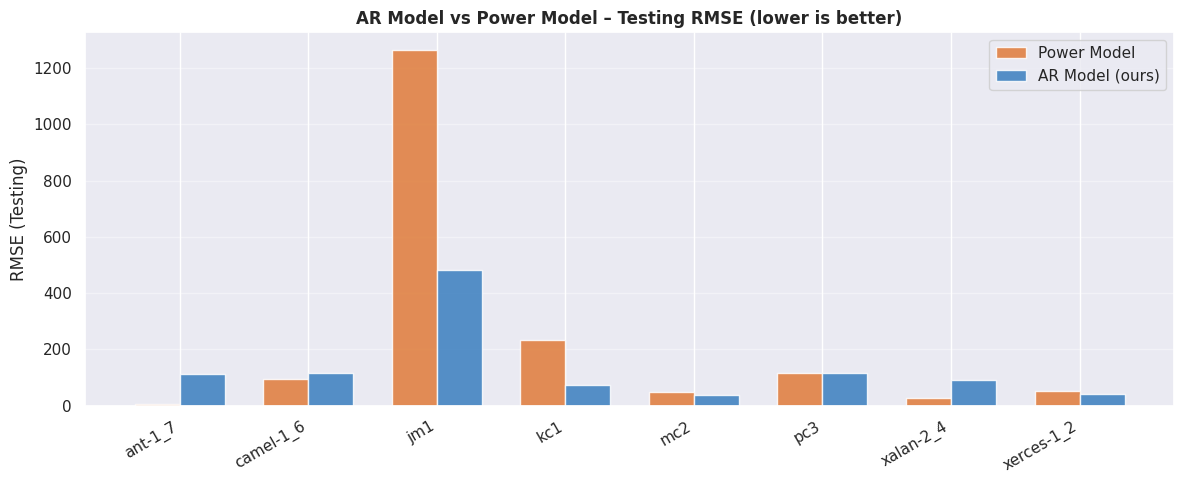

  Saved: ar_vs_power_rmse.png


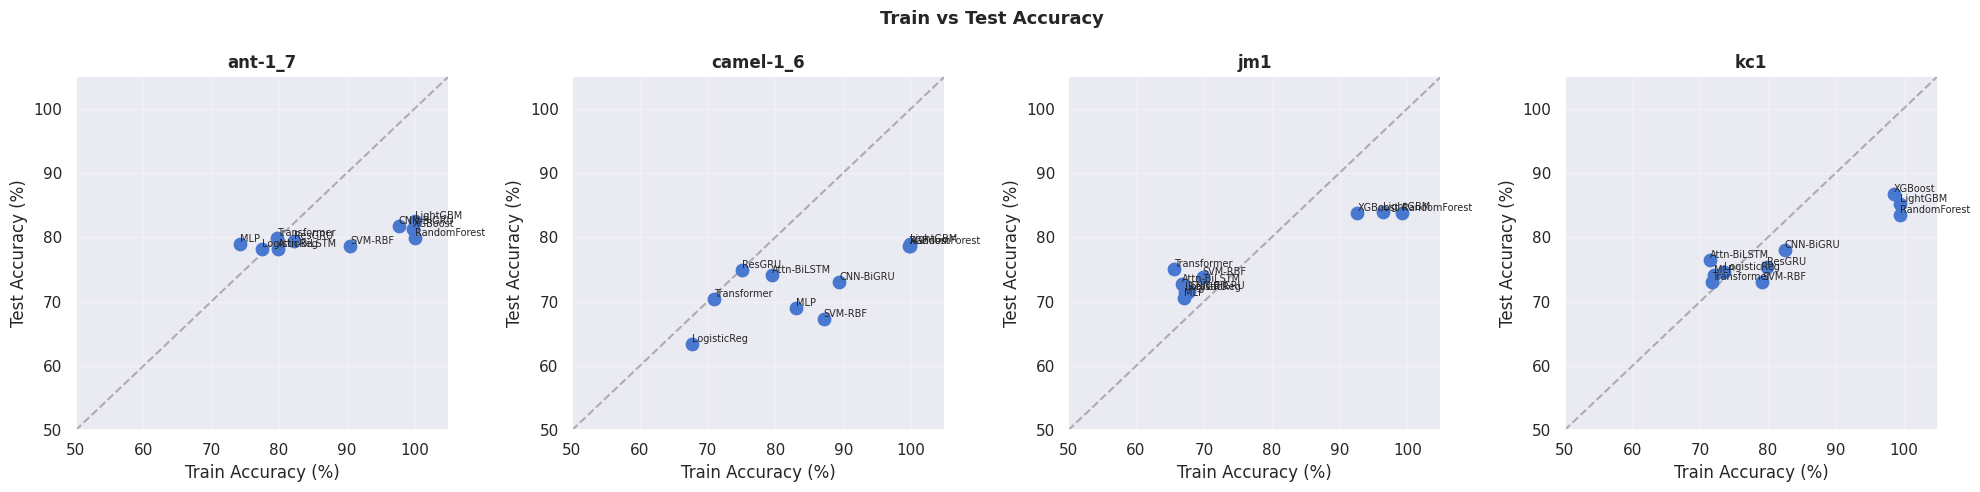

  Saved: train_vs_test_accuracy.png


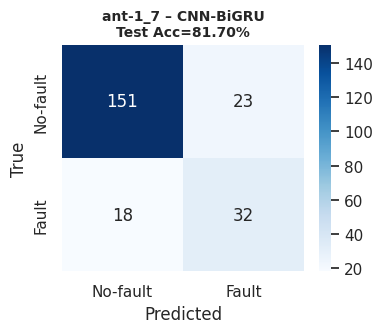

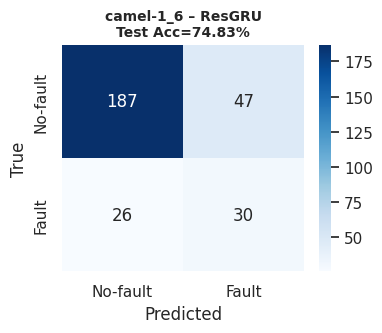

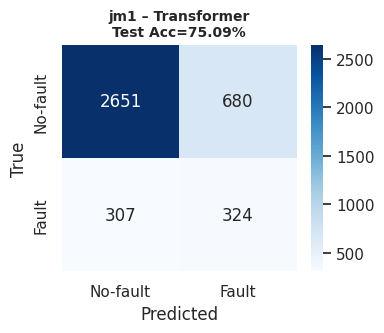

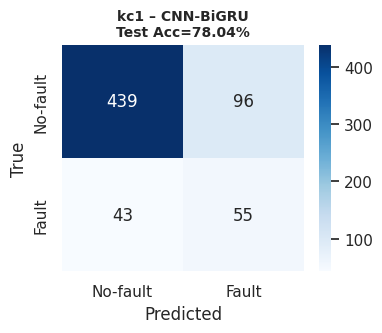

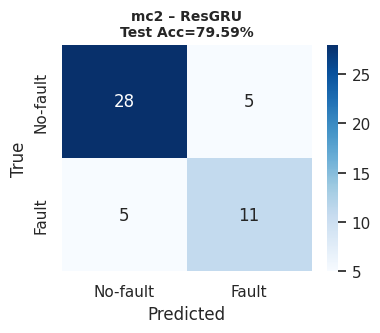

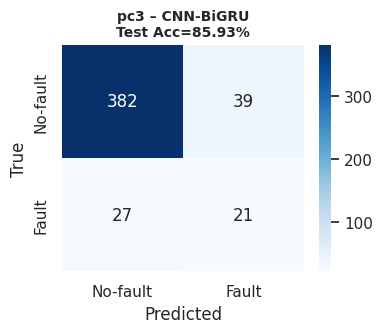

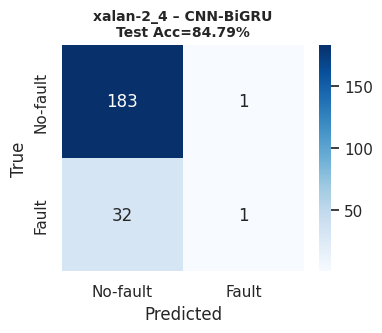

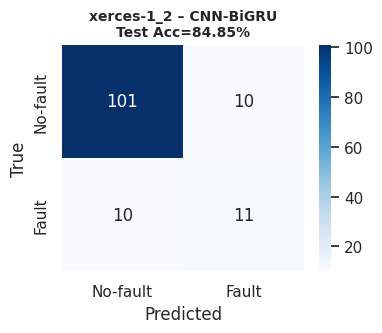


  All confusion matrices saved.


In [42]:
# ════════════════════════════════════════════════════════════
# CELL 9 – Comprehensive Visualizations
# ════════════════════════════════════════════════════════════

# ── 9a  Training & Validation Curves per Dataset ─────────
for ds_name, ds_res in ALL_RESULTS.items():
    dl_models = {k: v for k, v in ds_res.items()
                 if "history" in v}
    if not dl_models:
        continue

    fig, axes = plt.subplots(2, len(dl_models),
                             figsize=(5*len(dl_models), 8))
    fig.suptitle(f"Training Curves – {ds_name}", fontsize=14,
                 fontweight="bold", y=1.01)

    for col, (mname, mres) in enumerate(dl_models.items()):
        hist = mres["history"]
        ax_loss = axes[0, col] if len(dl_models) > 1 else axes[0]
        ax_acc  = axes[1, col] if len(dl_models) > 1 else axes[1]

        ax_loss.plot(hist["train_loss"], label="Train Loss", lw=2)
        ax_loss.plot(hist["val_loss"],   label="Val Loss",   lw=2)
        ax_loss.set_title(mname, fontweight="bold")
        ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss")
        ax_loss.legend(); ax_loss.grid(True, alpha=0.4)

        ax_acc.plot([a*100 for a in hist["train_acc"]],
                    label="Train Acc", lw=2)
        ax_acc.plot([a*100 for a in hist["val_acc"]],
                    label="Val Acc", lw=2)
        ax_acc.set_xlabel("Epoch"); ax_acc.set_ylabel("Accuracy (%)")
        ax_acc.legend(); ax_acc.grid(True, alpha=0.4)

    plt.tight_layout()
    plt.savefig(f"training_curves_{ds_name}.png", dpi=120,
                bbox_inches="tight")
    plt.show()
    print(f"  Saved: training_curves_{ds_name}.png")


# ── 9b  Summary Table – ALL metrics per dataset ──────────
print("\n\n" + "="*70)
print("  SUMMARY TABLE – Test Accuracy across all Models & Datasets")
print("="*70)

all_model_names = sorted({m for ds in ALL_RESULTS.values() for m in ds})
rows = []
for ds_name, ds_res in ALL_RESULTS.items():
    row = {"Dataset": ds_name}
    for mname in all_model_names:
        if mname in ds_res:
            row[mname] = f"{ds_res[mname]['test_acc']*100:.2f}%"
        else:
            row[mname] = "—"
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("Dataset")
print(summary_df.to_string())

# ── 9c  Heat-map of test accuracy ────────────────────────
acc_matrix = pd.DataFrame(index=list(ALL_RESULTS.keys()),
                           columns=all_model_names, dtype=float)
for ds_name, ds_res in ALL_RESULTS.items():
    for mname in all_model_names:
        if mname in ds_res:
            acc_matrix.loc[ds_name, mname] = \
                ds_res[mname]["test_acc"] * 100

fig, ax = plt.subplots(figsize=(max(10, len(all_model_names)*1.6),
                                 max(5, len(ALL_RESULTS)*0.9)))
sns.heatmap(acc_matrix.astype(float), annot=True, fmt=".1f",
            cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Test Accuracy (%)"})
ax.set_title("Test Accuracy (%) – All Models × All Datasets",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Model"); ax.set_ylabel("Dataset")
plt.tight_layout()
plt.savefig("heatmap_test_accuracy.png", dpi=130, bbox_inches="tight")
plt.show()
print("\n  Saved: heatmap_test_accuracy.png")


# ── 9d  AR vs Power RMSE comparison (paper replication) ──
if AR_PAPER_RESULTS:
    ds_names = list(AR_PAPER_RESULTS.keys())
    ar_rmse_te  = [AR_PAPER_RESULTS[d]["AR"]["RMSE-Testing"]    for d in ds_names]
    pow_rmse_te = [AR_PAPER_RESULTS[d]["Power"]["RMSE-Testing"] for d in ds_names]

    x = np.arange(len(ds_names))
    w = 0.35
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - w/2, pow_rmse_te, w, label="Power Model",
           color="#e07b39", alpha=0.85)
    ax.bar(x + w/2, ar_rmse_te,  w, label="AR Model (ours)",
           color="#3a7ebf", alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(ds_names, rotation=30, ha="right")
    ax.set_ylabel("RMSE (Testing)"); ax.set_title(
        "AR Model vs Power Model – Testing RMSE (lower is better)",
        fontweight="bold")
    ax.legend(); ax.grid(axis="y", alpha=0.4)
    plt.tight_layout()
    plt.savefig("ar_vs_power_rmse.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("  Saved: ar_vs_power_rmse.png")


# ── 9e  Train Acc vs Test Acc scatter ────────────────────
fig, axes = plt.subplots(1, min(4, len(ALL_RESULTS)),
                          figsize=(5*min(4, len(ALL_RESULTS)), 5))
if len(ALL_RESULTS) == 1:
    axes = [axes]

for ax, (ds_name, ds_res) in zip(axes, list(ALL_RESULTS.items())[:4]):
    tr_accs = [v["train_acc"]*100 for v in ds_res.values()
               if "train_acc" in v]
    te_accs = [v["test_acc"]*100  for v in ds_res.values()
               if "test_acc"  in v]
    names   = [k for k in ds_res if "train_acc" in ds_res[k]]

    ax.scatter(tr_accs, te_accs, s=80, zorder=3)
    for i, n in enumerate(names):
        ax.annotate(n, (tr_accs[i], te_accs[i]),
                    fontsize=7, ha="left", va="bottom")
    ax.plot([50, 105], [50, 105], "k--", alpha=0.3)
    ax.set_xlim(50, 105); ax.set_ylim(50, 105)
    ax.set_xlabel("Train Accuracy (%)"); ax.set_ylabel("Test Accuracy (%)")
    ax.set_title(ds_name, fontweight="bold"); ax.grid(alpha=0.3)

plt.suptitle("Train vs Test Accuracy", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("train_vs_test_accuracy.png", dpi=120, bbox_inches="tight")
plt.show()
print("  Saved: train_vs_test_accuracy.png")


# ── 9f  Confusion matrices (best DL model per dataset) ───
for ds_name, ds_res in ALL_RESULTS.items():
    dl_with_preds = {k: v for k, v in ds_res.items()
                     if "preds" in v}
    if not dl_with_preds:
        continue
    best_name = max(dl_with_preds,
                    key=lambda k: dl_with_preds[k]["test_acc"])
    res = dl_with_preds[best_name]

    cm = confusion_matrix(res["trues"], res["preds"])
    fig, ax = plt.subplots(figsize=(4, 3.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No-fault","Fault"],
                yticklabels=["No-fault","Fault"])
    ax.set_title(f"{ds_name} – {best_name}\n"
                 f"Test Acc={res['test_acc']*100:.2f}%",
                 fontweight="bold", fontsize=10)
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(f"confusion_{ds_name}.png", dpi=120, bbox_inches="tight")
    plt.show()

print("\n  All confusion matrices saved.")

In [43]:
# ════════════════════════════════════════════════════════════
# CELL 10 – Final Metrics Summary (Paper-Style Table)
# ════════════════════════════════════════════════════════════

print("\n\n" + "="*70)
print("  FINAL METRICS – Train Acc / Test Acc / Train Loss / Val Loss")
print("="*70)

for ds_name, ds_res in ALL_RESULTS.items():
    print(f"\n  ┌─ {ds_name} {'─'*(48-len(ds_name))}┐")
    print(f"  │ {'Model':<18} {'Train Acc':>10} {'Test Acc':>10} "
          f"{'Train Loss':>11} {'Val Loss':>9} │")
    print(f"  │{'─'*62}│")
    for mname, mres in ds_res.items():
        tr  = f"{mres.get('train_acc',0)*100:>9.2f}%"
        te  = f"{mres.get('test_acc',0)*100:>9.2f}%"
        tl  = f"{mres.get('train_loss',float('nan')):>10.4f}" \
               if "train_loss" in mres else f"{'N/A':>10}"
        vl  = f"{mres.get('val_loss',float('nan')):>8.4f}" \
               if "val_loss"   in mres else f"{'N/A':>8}"
        print(f"  │ {mname:<18} {tr} {te} {tl} {vl} │")
    print(f"  └{'─'*62}┘")

# ── AR / Power RMSE table ─────────────────────────────────
if AR_PAPER_RESULTS:
    print(f"\n\n  {'─'*55}")
    print("  AR vs Power Model – RMSE (replicating paper Tables 2-6)")
    print(f"  {'─'*55}")
    print(f"  {'Dataset':<14} {'Model':<8} "
          f"{'RMSE-Train':>12} {'RMSE-Test':>12}")
    print(f"  {'─'*55}")
    for ds_name, res in AR_PAPER_RESULTS.items():
        for mname, vals in res.items():
            print(f"  {ds_name:<14} {mname:<8} "
                  f"{vals['RMSE-Training']:>12.4f} "
                  f"{vals['RMSE-Testing']:>12.4f}")
    print(f"  {'─'*55}")

print("\n\n🎉  Notebook complete.  All plots saved as PNG files.\n")
print("  To download files from Colab:")
print("    from google.colab import files")
print("    files.download('heatmap_test_accuracy.png')")
print("    files.download('ar_vs_power_rmse.png')")



  FINAL METRICS – Train Acc / Test Acc / Train Loss / Val Loss

  ┌─ ant-1_7 ─────────────────────────────────────────┐
  │ Model               Train Acc   Test Acc  Train Loss  Val Loss │
  │──────────────────────────────────────────────────────────────│
  │ RandomForest          100.00%     79.91%        N/A      N/A │
  │ SVM-RBF                90.49%     78.57%        N/A      N/A │
  │ LogisticReg            77.41%     78.12%        N/A      N/A │
  │ XGBoost                99.75%     81.25%        N/A      N/A │
  │ LightGBM              100.00%     82.59%        N/A      N/A │
  │ MLP                    74.20%     79.02%     0.4589   0.5283 │
  │ Attn-BiLSTM            79.88%     78.12%     0.4092   0.5214 │
  │ ResGRU                 82.22%     79.46%     0.4141   0.5146 │
  │ Transformer            79.75%     79.91%     0.4719   0.5270 │
  │ CNN-BiGRU              97.65%     81.70%     0.1945   0.6778 │
  └──────────────────────────────────────────────────────────────┘

  ┌─